# 02 — Feature Engineering & Splits

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from src.data import load_raw, prepare_and_save, load_processed
from src.features import physics_features, polynomial_pairs
from src.config import FEATURE_COLS, TARGET_COL, FIGURES_DIR
sns.set_theme(style='whitegrid')

In [2]:
df = load_raw()
phys = physics_features(df.head(50_000))
phys.head()

,OSNR,Launch_Power,Fiber_Length,Dispersion,Nonlinear_Effect,osnr_over_nl,power_x_length,disp_x_length,nl_x_power,log_osnr,log_power
0,0.374540,0.950714,0.731994,0.598658,0.156019,2.400596,0.695917,0.438214,0.148329,0.318119,0.668196
1,0.155995,0.058084,0.866176,0.601115,0.708073,0.220308,0.050311,0.520671,0.041127,0.144961,0.056459
2,0.020584,0.969910,0.832443,0.212339,0.181825,0.113210,0.807394,0.176760,0.176354,0.020375,0.677988
3,0.183405,0.304242,0.524756,0.431945,0.291229,0.629758,0.159653,0.226666,0.088604,0.168395,0.265622
4,0.611853,0.139494,0.292145,0.366362,0.456070,1.341574,0.040752,0.107031,0.063619,0.477384,0.130584


In [3]:
poly = polynomial_pairs(df.head(50_000)[FEATURE_COLS])
print('poly shape:', poly.shape)
poly.head()

poly shape: (50000, 20)


,OSNR,Launch_Power,Fiber_Length,Dispersion,Nonlinear_Effect,OSNR_x_OSNR,OSNR_x_Launch_Power,OSNR_x_Fiber_Length,OSNR_x_Dispersion,OSNR_x_Nonlinear_Effect,Launch_Power_x_Launch_Power,Launch_Power_x_Fiber_Length,Launch_Power_x_Dispersion,Launch_Power_x_Nonlinear_Effect,Fiber_Length_x_Fiber_Length,Fiber_Length_x_Dispersion,Fiber_Length_x_Nonlinear_Effect,Dispersion_x_Dispersion,Dispersion_x_Nonlinear_Effect,Nonlinear_Effect_x_Nonlinear_Effect
0,0.374540,0.950714,0.731994,0.598658,0.156019,0.140280,0.356081,0.274161,0.224222,0.058435,0.903858,0.695917,0.569153,0.148329,0.535815,0.438214,0.114205,0.358392,0.093402,0.024342
1,0.155995,0.058084,0.866176,0.601115,0.708073,0.024334,0.009061,0.135119,0.093771,0.110455,0.003374,0.050311,0.034915,0.041127,0.750261,0.520671,0.613316,0.361339,0.425633,0.501367
2,0.020584,0.969910,0.832443,0.212339,0.181825,0.000424,0.019965,0.017135,0.004371,0.003743,0.940725,0.807394,0.205950,0.176354,0.692961,0.176760,0.151359,0.045088,0.038609,0.033060
3,0.183405,0.304242,0.524756,0.431945,0.291229,0.033637,0.055799,0.096243,0.079221,0.053413,0.092563,0.159653,0.131416,0.088604,0.275369,0.226666,0.152824,0.186576,0.125795,0.084814
4,0.611853,0.139494,0.292145,0.366362,0.456070,0.374364,0.085350,0.178750,0.224160,0.279048,0.019459,0.040752,0.051105,0.063619,0.085348,0.107031,0.133238,0.134221,0.167087,0.208000


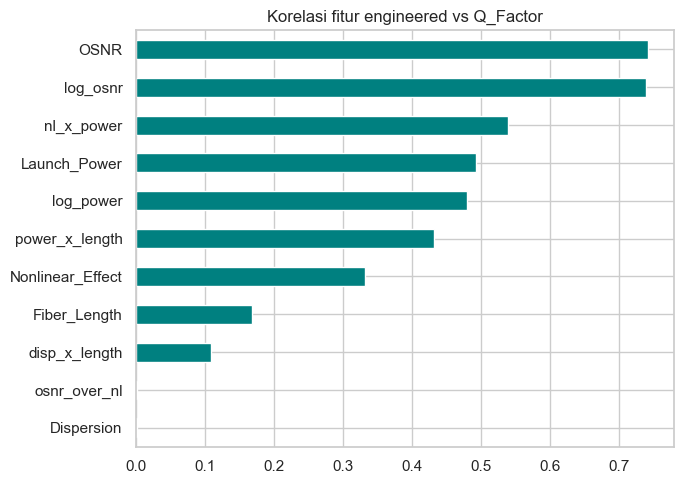

In [4]:
combined = pd.concat([phys, df.head(50_000)[TARGET_COL]], axis=1)
corr_target = combined.corr()[TARGET_COL].drop(TARGET_COL).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
corr_target.plot.barh(ax=ax, color='teal'); ax.set_title('Korelasi fitur engineered vs Q_Factor')
plt.tight_layout(); plt.savefig(FIGURES_DIR / '02_engineered_corr.png', dpi=120); plt.show()

## Persiapkan & simpan splits (70/15/15) + scaler

In [5]:
prepare_and_save()
for n in ['train', 'val', 'test']:
    X, y = load_processed(n); print(n, X.shape, y.shape)

train (699999, 5) (699999,)
val (150000, 5) (150000,)
test (150001, 5) (150001,)
